In [1]:
pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing 

In [2]:
"""
Module de création de carte de navigation à partir d'images segmentées
Divisé en parties modulaires pour faciliter le développement itératif (MVP)
"""

import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import segmentation_models_pytorch as smp
from scipy import ndimage
from matplotlib.colors import ListedColormap

In [3]:

#############################################################
# PARTIE 1: MODÈLE ET STRUCTURE DE DONNÉES
#############################################################

def build_unet_model(input_size=(256, 256, 3)):
    """
    Construit un modèle U-Net pour la segmentation d'image.
    
    Args:
        input_size: Taille des images d'entrée (hauteur, largeur, canaux)
        
    Returns:
        Un modèle PyTorch U-Net
    """
    model = smp.Unet(
        encoder_name="resnet50",      # Encodeur ResNet50
        encoder_weights="imagenet",   # Poids pré-entraînés sur ImageNet
        classes=1,                    # Segmentation binaire
        activation='sigmoid'          # Activation sigmoid
    )
    
    model.eval()  # Mode évaluation par défaut
    return model


class SimpleNavigationMap:
    """Classe pour la création d'une carte de navigation à partir d'une image segmentée."""
    
    # Constantes pour les valeurs de la grille
    EMPTY = 0    # Chemin libre
    OBSTACLE = 1 # Obstacle
    
    def __init__(self, width_meters=40, height_meters=25, cell_size=2.5):
        """Initialise une carte de navigation avec les dimensions spécifiées."""
        # Ajuster pour avoir ~1000 m²
        if abs(width_meters * height_meters - 1000) > 50:
            ratio = np.sqrt(1000 / (width_meters * height_meters))
            width_meters = int(width_meters * ratio)
            height_meters = int(height_meters * ratio)
            print(f"Dimensions ajustées: {width_meters}m x {height_meters}m = {width_meters * height_meters}m²")
        
        self.width_meters = width_meters
        self.height_meters = height_meters
        self.cell_size = cell_size
        
        # Calculer les dimensions de la grille
        self.grid_cols = int(width_meters / cell_size)
        self.grid_rows = int(height_meters / cell_size)
        
        # Initialiser une grille vide
        self.grid = np.zeros((self.grid_rows, self.grid_cols), dtype=int)
        
        print(f"Carte de navigation créée: {width_meters}m x {height_meters}m avec des cellules de {cell_size}m")
        print(f"Dimensions de la grille: {self.grid_cols} colonnes x {self.grid_rows} lignes")



In [4]:
#############################################################
# PARTIE 2: SEGMENTATION D'IMAGE (SANS PRÉTRAITEMENT)
#############################################################

def segment_with_model(image, model, target_size=(400, 400)):
    """
    Segmente l'image avec un modèle U-Net.
    
    Args:
        image: Image à segmenter
        model: Modèle U-Net
        target_size: Taille cible pour le redimensionnement
    
    Returns:
        La segmentation prédite
    """
    # Redimensionner l'image
    resized = cv2.resize(image, target_size)
    
    # Prétraitement pour le modèle
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    normalized = resized.astype(np.float32) / 255.0
    for i in range(3):
        normalized[:,:,i] = (normalized[:,:,i] - mean[i]) / std[i]
    
    # Convertir en tensor PyTorch
    tensor = torch.from_numpy(normalized).permute(2, 0, 1).unsqueeze(0).float()
    
    # Effectuer l'inférence
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tensor = tensor.to(device)
    model = model.to(device)
    
    with torch.no_grad():
        prediction = model(tensor)
    
    # Convertir la prédiction en array NumPy
    segmentation = prediction.squeeze().cpu().numpy()
    return segmentation


def segment_with_edges(image, target_size=(400, 400)):
    """
    Simule une segmentation en utilisant la détection de bords.
    
    Args:
        image: Image à segmenter
        target_size: Taille cible pour le redimensionnement
    
    Returns:
        La segmentation simulée
    """
    # Redimensionner l'image
    resized = cv2.resize(image, target_size)
    
    # Convertir en niveaux de gris
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    
    # Appliquer un flou gaussien
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Détecter les bords avec Canny
    edges = cv2.Canny(blurred, 50, 150)
    
    # Dilater les bords pour les rendre plus visibles
    kernel = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=1)
    
    # Normaliser
    segmentation = dilated / 255.0
    return segmentation


In [5]:
#############################################################
# PARTIE 3: TRAITEMENT DE LA SEGMENTATION
#############################################################

def majority_filter(image, ksize=5):
    """
    Applique un filtre de majorité pour lisser l'image binaire.
    
    Args:
        image: Image binaire à lisser
        ksize: Taille du noyau de filtrage
    
    Returns:
        Image lissée
    """
    padded = cv2.copyMakeBorder(image, ksize//2, ksize//2, ksize//2, ksize//2, cv2.BORDER_REPLICATE)
    result = np.zeros_like(image)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            window = padded[y:y+ksize, x:x+ksize]
            white = np.sum(window == 255)
            black = np.sum(window == 0)
            result[y, x] = 255 if white >= black else 0
    return result


def max_pooling(image, ksize=2):
    """
    Applique un pooling maximum sur l'image.
    
    Args:
        image: Image à pooler
        ksize: Taille du noyau de pooling
    
    Returns:
        Image poolée
    """
    pooled = np.zeros_like(image)
    for y in range(0, image.shape[0], ksize):
        for x in range(0, image.shape[1], ksize):
            y_end = min(y + ksize, image.shape[0])
            x_end = min(x + ksize, image.shape[1])
            window = image[y:y_end, x:x_end]
            if window.size > 0:
                pooled_value = np.max(window)
                pooled[y:y_end, x:x_end] = pooled_value
    return pooled


def do_bboxes_intersect(bbox1, bbox2):
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2

    return not (x1 + w1 < x2 or x2 + w2 < x1 or y1 + h1 < y2 or y2 + h2 < y1)


def shrink_bbox(x, y, w, h, shrink_ratio=0.8, img=None):
    """
    Réduit dynamiquement un bounding box tout en maintenant son attachement
    en haut/bas/gauche/droite selon sa position dans l'image.
    """
    if img is None:
        raise ValueError("L'image est requise pour obtenir les dimensions.")

    img_height, img_width = img.shape[:2]
    
    # Réduire largeur et hauteur
    new_w = int(w * shrink_ratio)
    new_h = int(h * shrink_ratio)

    # Position verticale (Y)
    if y + h / 2 < img_height / 2:
        new_y = y
    else:
        new_y = y + h - new_h

    # Position horizontale (X)
    if x + w / 2 < img_width / 2:
        new_x = x
    else:
        new_x = x + w - new_w

    return new_x, new_y, new_w, new_h


def draw_non_overlapping_bboxes(contours, navigation_map, img, shrink_ratio=0.7):
    boxes = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        bbox = (x, y, w, h)

        # Vérifier les chevauchements
        intersects = False
        for existing_bbox in boxes:
            if do_bboxes_intersect(existing_bbox, bbox):
                intersects = True
                break

        if intersects:
            # Réduire la taille pour éviter le chevauchement
            bbox = shrink_bbox(x, y, w, h, shrink_ratio=shrink_ratio, img=img)

        # Ajouter la boîte (modifiée ou non)
        boxes.append(bbox)

        # Dessiner la boîte sur la carte
        bx, by, bw, bh = bbox
        cv2.rectangle(navigation_map, (bx, by), (bx + bw, by + bh), 0, thickness=-1)

    return navigation_map


def process_segmentation(segmentation):
    """
    Traite la segmentation brute pour obtenir une carte binaire des obstacles.
    
    Args:
        segmentation: Segmentation brute (valeurs entre 0 et 1)
    
    Returns:
        Trois éléments: 
        - Une matrice binaire où 0=chemin libre et 1=obstacle
        - L'image après pooling
        - L'image après redimensionnement du pooling
    """
    # Convertir en image 8-bit
    img = (segmentation * 255).astype(np.uint8)
    
    # Binarisation
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    
    # Opérations morphologiques
    kernel_1x1 = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
    
    # Première dilatation
    dilated_first = cv2.dilate(binary, kernel_1x1, iterations=2)
    
    # Deuxième dilatation
    dilated_second = cv2.dilate(dilated_first, kernel_1x1, iterations=1)
    
    # Fermeture avec noyau 1x1 (tu avais mis "3x3" dans le commentaire, mais (1,1) dans le code)
    kernel_3x3 = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
    closed = cv2.morphologyEx(dilated_second, cv2.MORPH_CLOSE, kernel_3x3)
    
    # Erosion
    eroded = cv2.erode(closed, kernel_1x1, iterations=1)
    
    # Remplir les obstacles (contours)
    contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(eroded)
    cv2.drawContours(filled, contours, -1, 255, thickness=cv2.FILLED)
    
    # Appliquer le majority filter (11x11 ici)
    smoothed = majority_filter(filled, ksize=11)
    
    # Max pooling (2x2)
    pooled = max_pooling(smoothed, ksize=2)
    
    # Redimensionner à la taille originale
    pooled_resized = cv2.resize(pooled, (smoothed.shape[1], smoothed.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    # Contours sur image finale
    final_contours, _ = cv2.findContours(pooled_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Carte blanche
    navigation_map = np.ones_like(pooled_resized) * 255
    
    # Dessin des boîtes sans chevauchement
    navigation_map = draw_non_overlapping_bboxes(final_contours, navigation_map, img)
    
    # Carte binaire 0=libre, 1=obstacle
    navigation_map_binary = (255 - navigation_map) // 255
    
    return navigation_map, pooled, pooled_resized


In [6]:
#############################################################
# PARTIE 4: CRÉATION DE LA CARTE DE NAVIGATION
#############################################################


def create_navigation_map(image_path=None, obstacle_map=None, model_path=None, cell_size=2.5, 
                         width_meters=None, height_meters=None):
    """
    Crée une carte de navigation soit à partir d'une image, soit à partir d'une carte d'obstacles existante.
    
    Args:
        image_path: Chemin vers l'image (ignoré si obstacle_map est fourni)
        obstacle_map: Carte binaire des obstacles déjà générée (prioritaire sur image_path)
        model_path: Chemin vers un modèle U-Net pré-entraîné (utilisé seulement si obstacle_map n'est pas fourni)
        cell_size: Taille des cellules en mètres
        width_meters: Largeur de la carte en mètres (facultatif)
        height_meters: Hauteur de la carte en mètres (facultatif)
    
    Returns:
        La carte de navigation et les éléments intermédiaires pour la visualisation
    """
    # Si une carte d'obstacles est fournie, l'utiliser directement
    if obstacle_map is not None:
        nav_map = create_navigation_map_from_binary(obstacle_map, width_meters, height_meters, cell_size)
        # Retourner les informations nécessaires pour la visualisation
        return nav_map, None, None, obstacle_map, None, None
    
    # Sinon, générer à partir de l'image comme avant
    if image_path is None:
        raise ValueError("Vous devez fournir soit obstacle_map soit image_path")
        
    # Charger l'image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Impossible de charger l'image: {image_path}")
    
    # Convertir en RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image_rgb.shape[:2]
    aspect_ratio = width / height
    
    # Estimer les dimensions en mètres pour avoir ~1000m² si non fournies
    if width_meters is None or height_meters is None:
        area_m2 = 1000
        height_meters = np.sqrt(area_m2 / aspect_ratio)
        width_meters = height_meters * aspect_ratio
    
    # Créer une carte de navigation vide
    nav_map = SimpleNavigationMap(round(width_meters), round(height_meters), cell_size)
    
    # Segmenter l'image
    target_size = (width, height)  # Utiliser les dimensions originales
    
    # Charger le modèle ou utiliser une segmentation basée sur les bords
    if model_path and torch.cuda.is_available():
        try:
            print(f"Chargement du modèle U-Net: {model_path}")
            device = torch.device("cuda")
            unet_model = torch.load(model_path, map_location=device)
            segmentation = segment_with_model(image_rgb, unet_model, target_size)
        except Exception as e:
            print(f"Erreur lors du chargement du modèle: {e}")
            print("Utilisation de la segmentation basée sur les bords")
            segmentation = segment_with_edges(image_rgb, target_size)
    else:
        print("Utilisation de la segmentation basée sur les bords")
        segmentation = segment_with_edges(image_rgb, target_size)
    
    # Traiter la segmentation
    navigation_map_binary, pooled, pooled_resized = process_segmentation(segmentation)
    
    # Redimensionner à la taille de la grille
    navigation_grid = cv2.resize(navigation_map_binary, (nav_map.grid_cols, nav_map.grid_rows), 
                                interpolation=cv2.INTER_NEAREST)
    
    # Mettre à jour la grille de navigation
    nav_map.grid = navigation_grid.astype(int)
    
    return nav_map, image_rgb, segmentation, navigation_map_binary, pooled, pooled_resized


class SimpleNavigationMap:
    """
    Classe représentant une carte de navigation simple.
    """
    def __init__(self, width_meters, height_meters, cell_size=2.5):
        """
        Initialise une carte de navigation.
        
        Args:
            width_meters: Largeur de la carte en mètres
            height_meters: Hauteur de la carte en mètres
            cell_size: Taille des cellules en mètres
        """
        self.width_meters = width_meters
        self.height_meters = height_meters
        self.cell_size = cell_size
        
        # Calculer les dimensions de la grille
        self.grid_cols = int(np.ceil(width_meters / cell_size))
        self.grid_rows = int(np.ceil(height_meters / cell_size))
        
        # Initialiser la grille (0=libre, 1=obstacle)
        self.grid = np.zeros((self.grid_rows, self.grid_cols), dtype=int)
    
    def is_navigable(self, x, y):
        """
        Vérifie si une position est navigable.
        
        Args:
            x, y: Coordonnées en mètres
        
        Returns:
            True si la position est navigable, False sinon
        """
        # Convertir les coordonnées métriques en indices de grille
        col = int(x / self.cell_size)
        row = int(y / self.cell_size)
        
        # Vérifier si les indices sont dans les limites
        if 0 <= row < self.grid_rows and 0 <= col < self.grid_cols:
            # Retourner True si la cellule est libre (0), False si c'est un obstacle (1)
            return self.grid[row, col] == 0
        
        # Par défaut, considérer comme non navigable si hors limites
        return False
    
    def visualize(self, show_grid=True):
        """
        Visualise la carte de navigation.
        
        Args:
            show_grid: Afficher ou non la grille
        
        Returns:
            Image de la carte de navigation
        """
        # Créer une image RGB (blanc=libre, noir=obstacle)
        visualization = np.zeros((self.grid_rows, self.grid_cols, 3), dtype=np.uint8)
        visualization[self.grid == 0] = [255, 255, 255]  # Blanc pour les zones libres
        
        # Agrandir l'image pour une meilleure visualisation
        scale_factor = 5
        visualization = cv2.resize(visualization, 
                                  (self.grid_cols * scale_factor, self.grid_rows * scale_factor), 
                                  interpolation=cv2.INTER_NEAREST)
        
        # Ajouter la grille si demandé
        if show_grid:
            # Lignes horizontales
            for i in range(0, self.grid_rows * scale_factor, scale_factor):
                visualization[i, :] = [200, 200, 200]
            
            # Lignes verticales
            for j in range(0, self.grid_cols * scale_factor, scale_factor):
                visualization[:, j] = [200, 200, 200]
        
        return visualization

In [7]:
#############################################################
# PARTIE 5: VISUALISATION ET EXPORT
#############################################################

def visualize_full_process(image_path, nav_map, image_rgb, segmentation, 
                           navigation_map_binary, pooled, pooled_resized):
    """
    Visualise le processus complet de segmentation et de création de la carte.
    
    Args:
        image_path: Chemin vers l'image originale
        nav_map: Carte de navigation générée
        image_rgb: Image RGB
        segmentation: Segmentation brute
        navigation_map_binary: Carte binaire des obstacles
        pooled: Image après pooling
        pooled_resized: Image après redimensionnement du pooling
    """
    # Créer une figure avec 6 sous-graphiques
    plt.figure(figsize=(16, 12))
    
    # 1. Image originale
    plt.subplot(2, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Image originale")
    plt.axis('off')
    
    # 2. Segmentation brute
    plt.subplot(2, 3, 2)
    plt.imshow(segmentation, cmap='gray')
    plt.title("Segmentation brute")
    plt.axis('off')
    
    # 3. Binarisation
    binary = (segmentation * 255).astype(np.uint8)
    _, binary = cv2.threshold(binary, 127, 255, cv2.THRESH_BINARY)
    plt.subplot(2, 3, 3)
    plt.imshow(binary, cmap='gray')
    plt.title("Binarisation")
    plt.axis('off')
    
    # 4. Image après pooling
    plt.subplot(2, 3, 4)
    plt.imshow(pooled, cmap='gray')
    plt.title("Après pooling")
    plt.axis('off')
    
    # 5. Image après redimensionnement du pooling
    plt.subplot(2, 3, 5)
    plt.imshow(pooled_resized, cmap='gray')
    plt.title("Après redimensionnement")
    plt.axis('off')
    
    # 6. Carte de navigation binaire
    plt.subplot(2, 3, 6)
    plt.imshow(navigation_map_binary, cmap='gray')
    plt.title("Carte binaire des obstacles")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Afficher la carte de navigation superposée à l'image originale
    #visualize_navigation_map(nav_map, image_path)


def visualize_navigation_map(nav_map, image_path=None):
    """
    Visualise la carte de navigation.
    
    Args:
        nav_map: Carte de navigation à visualiser
        image_path: Chemin vers l'image originale (facultatif)
    """
    plt.figure(figsize=(12, 10))
    
    # Si l'image originale est fournie, l'afficher en arrière-plan
    if image_path:
        original = cv2.imread(image_path)
        if original is not None:
            original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
            resized_original = cv2.resize(original_rgb, (nav_map.grid_cols, nav_map.grid_rows))
            plt.imshow(resized_original, alpha=0.6)
    
    # Définir une palette de couleurs
    colors = ['none', 'red']
    cmap = ListedColormap(colors)
    
    # Afficher uniquement les obstacles
    mask = nav_map.grid > 0
    plt.imshow(np.ma.masked_where(~mask, nav_map.grid), cmap=cmap, alpha=0.7)
    
    # Ajouter une grille pour visualiser les cellules
    plt.grid(which='both', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Créer des positions de ticks qui s'adaptent à la taille de la grille
    x_step = max(1, nav_map.grid_cols // 8)  # Diviser la grille en environ 8 sections
    y_step = max(1, nav_map.grid_rows // 8)
    
    x_positions = np.arange(0, nav_map.grid_cols, x_step)
    y_positions = np.arange(0, nav_map.grid_rows, y_step)
    
    x_labels = [f"{int(pos * nav_map.cell_size)}" for pos in x_positions]
    y_labels = [f"{int(pos * nav_map.cell_size)}" for pos in y_positions]
    
    plt.xticks(x_positions, x_labels)
    plt.yticks(y_positions, y_labels)
    
    # Ajouter une légende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='none', edgecolor='gray', label='Chemin'),
        Patch(facecolor='red', edgecolor='gray', alpha=0.7, label='Obstacle')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.title(f"Carte de navigation ({nav_map.width_meters:.1f}m × {nav_map.height_meters:.1f}m)")
    plt.xlabel("Distance (m)")
    plt.ylabel("Distance (m)")
    plt.tight_layout()
    plt.show()


def export_navigation_map(nav_map, output_path):
    """
    Exporte la carte de navigation au format CSV ou NPY.
    
    Args:
        nav_map: Carte de navigation à exporter
        output_path: Chemin de sortie pour le fichier
    """
    if output_path.endswith('.csv'):
        np.savetxt(output_path, nav_map.grid, delimiter=',', fmt='%d')
        print(f"Carte de navigation exportée au format CSV: {output_path}")
    elif output_path.endswith('.npy'):
        np.save(output_path, nav_map.grid)
        print(f"Carte de navigation exportée au format NPY: {output_path}")
    else:
        print(f"Format de fichier non reconnu. Veuillez utiliser .csv ou .npy")



Segmentation de l'image: /kaggle/input/wareh1/wareH.jpg
Chargement du modèle U-Net: 2.5
Erreur lors du chargement du modèle: 'float' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.
Utilisation de la segmentation basée sur les bords


/tmp/ipykernel_31/135113866.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_model = torch.load(model_path, map_location=device)


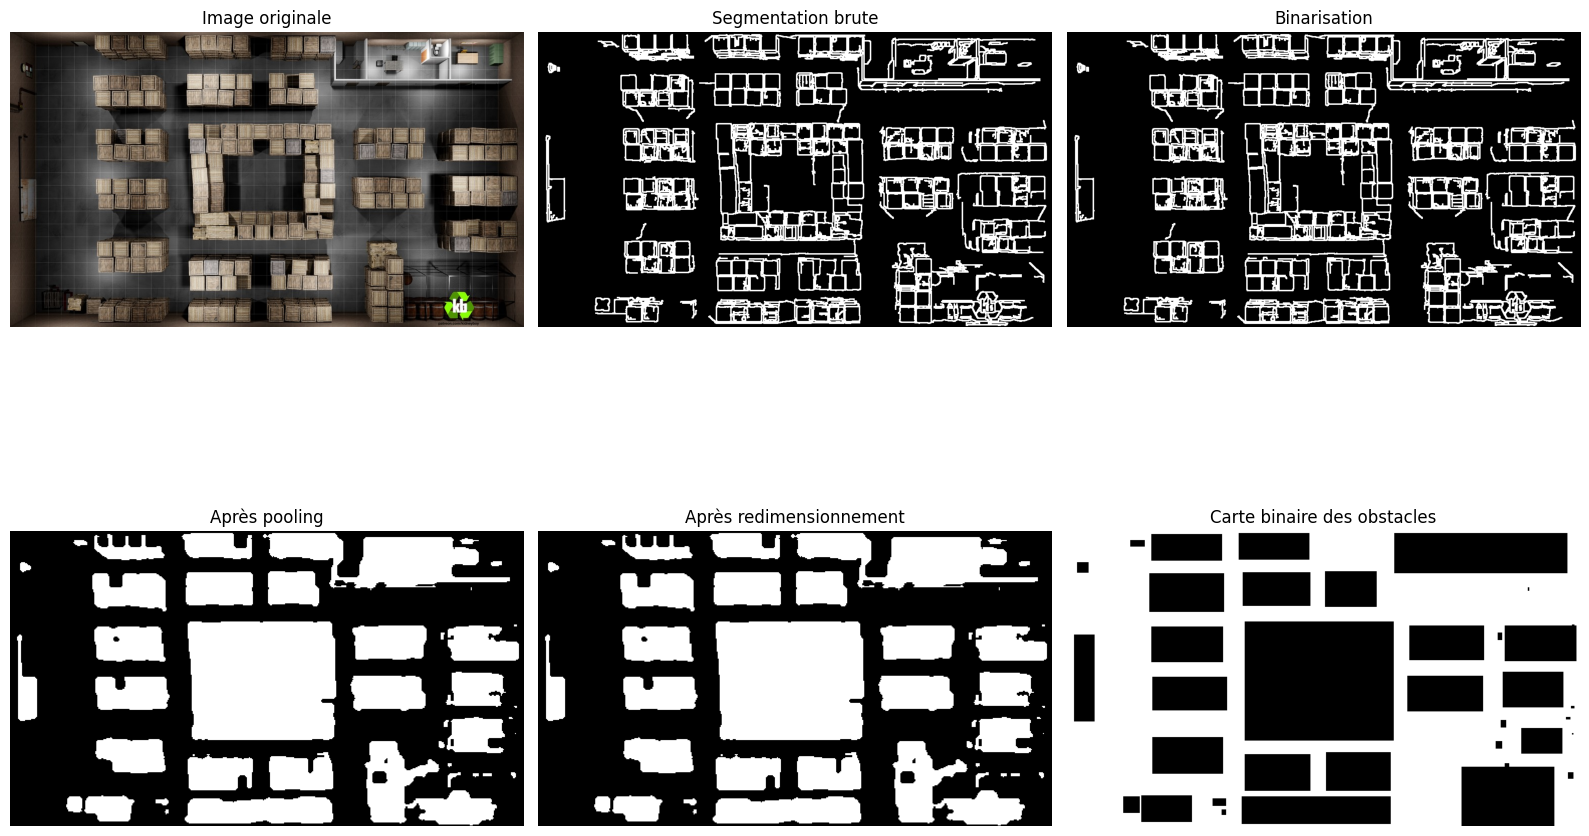

Carte de navigation exportée au format CSV: navigation_map.csv


In [8]:
#############################################################
# PARTIE 6: FONCTION PRINCIPALE ET USAGE
#############################################################

import cv2
import numpy as np

def main(image_path, model_path=None, cell_size=2.5, output_path=None):
    """
    Fonction principale pour segmenter une image et créer une carte de navigation.
    
    Args:
        image_path: Chemin vers l'image à segmenter
        model_path: Chemin vers un modèle U-Net pré-entraîné (facultatif)
        cell_size: Taille des cellules en mètres
        output_path: Chemin pour exporter la carte de navigation (facultatif)
    """
    print(f"Segmentation de l'image: {image_path}")
    
    # Créer la carte de navigation et récupérer les éléments intermédiaires
    nav_map, image_rgb, segmentation, navigation_map_binary, pooled, pooled_resized = \
        create_navigation_map(image_path, model_path, cell_size)
    
    # 🔷 Étape 1 : Conversion en carte d’obstacles (1 = obstacle, 0 = libre)
    obstacle_map = np.where(navigation_map_binary == 0, 1, 0).astype(np.uint8)
    
    # 🔷 Étape 2 : Dilatation (optionnel, à ajuster selon la taille du robot)
    kernel = np.ones((5, 5), np.uint8)  # (5x5) ou autre selon besoin
    obstacle_map_dilated = cv2.dilate(obstacle_map, kernel, iterations=1)
    
    
    # Visualiser le processus complet
    visualize_full_process(image_path, nav_map, image_rgb, segmentation, 
                          navigation_map_binary, pooled, pooled_resized)
    
    # Exporter la carte si demandé
    if output_path:
        export_navigation_map(nav_map, output_path)
    
    return nav_map,obstacle_map_dilated



if __name__ == "__main__":
    # Exemple d'utilisation
    image_path = r"/kaggle/input/wareh1/wareH.jpg"  # Remplacer par le chemin de votre image
    model_path = None  # Remplacer par le chemin de votre modèle U-Net si disponible
    
    # Segmenter l'image et créer une carte de navigation
    nav_map ,obstacle_map_dilated= main(image_path, model_path, cell_size=2.5, output_path="navigation_map.csv")

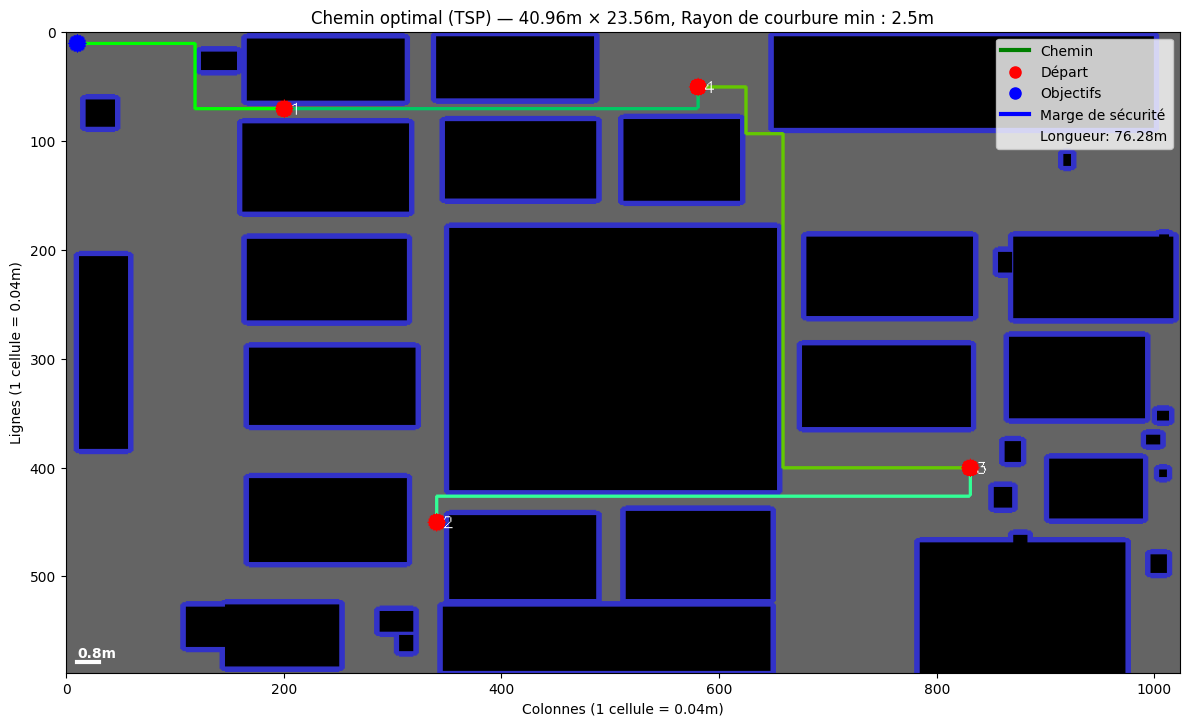

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from itertools import permutations
from queue import PriorityQueue
import math

def manhattan_distance(point1, point2):
    return abs(point1[0] - point2[0]) + abs(point1[1] - point2[1])

def euclidean_distance(point1, point2):
    return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

def astar(map_binary, start, goal, diagonal_movement=False, safety_margin=5):
    """
    A* algorithm with safety distance from obstacles and smoother paths
    """
    h, w = map_binary.shape
    visited = set()
    came_from = {}
    g_score = {start: 0}
    f_score = {start: manhattan_distance(start, goal)}
    open_set = PriorityQueue()
    open_set.put((f_score[start], id(start), start))

    if diagonal_movement:
        directions = [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]
    else:
        # Pour forcer les angles de 90 degrés, on utilise uniquement des mouvements orthogonaux
        directions = [(-1,0), (1,0), (0,-1), (0,1)]

    while not open_set.empty():
        _, _, current = open_set.get()
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        visited.add(current)

        for dx, dy in directions:
            neighbor = (current[0]+dx, current[1]+dy)

            if not (0 <= neighbor[0] < h and 0 <= neighbor[1] < w):
                continue
                
            # Vérifier la distance de sécurité par rapport aux obstacles
            # On vérifie si le point est valide dans la carte dilatée
            if map_binary[neighbor] == 0:
                continue

            move_cost = 1.4 if (dx != 0 and dy != 0) else 1.0
            tentative_g = g_score[current] + move_cost

            # Ajouter une pénalité pour les changements de direction
            # afin de favoriser les chemins rectilignes
            if current in came_from:
                prev = came_from[current]
                prev_dir = (current[0] - prev[0], current[1] - prev[1])
                if (dx, dy) != prev_dir:
                    tentative_g += 1.5  # Pénalité pour changement de direction

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score[neighbor] = tentative_g + manhattan_distance(neighbor, goal)
                if neighbor not in visited:
                    open_set.put((f_score[neighbor], id(neighbor), neighbor))

    return None

def apply_safety_margin(map_binary, safety_cells):
    """
    Dilate les obstacles pour garantir une distance de sécurité
    """
    if safety_cells <= 0:
        return map_binary.copy()
        
    # Créer un élément structurant circulaire
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*safety_cells+1, 2*safety_cells+1))
    
    # Dilater les obstacles (0 = obstacle, 1 = espace libre)
    dilated_map = cv2.erode(map_binary.astype(np.uint8), kernel, iterations=1)
    
    return dilated_map



def add_curve_to_path(path, curve_radius_meters=2.5, point_size_meters=1.0):
    """
    Remplace les virages du chemin par des arcs de cercle lissés.
    Args:
        path: Liste de tuples (x, y)
        curve_radius_meters: Rayon minimal de courbe
        point_size_meters: Distance entre deux points dans le chemin
    Returns:
        Nouveau chemin lissé
    """
    if len(path) < 3:
        return path
    
    new_path = []
    r = max(curve_radius_meters, point_size_meters * 2)
    
    # Ajouter le premier point
    new_path.append(path[0])
    
    # Traiter tous les points intermédiaires
    for i in range(1, len(path) - 1):
        A = path[i - 1]  # Point précédent
        B = path[i]      # Point courant
        C = path[i + 1]  # Point suivant
        
        # Vecteurs AB et BC
        AB = (B[0] - A[0], B[1] - A[1])
        BC = (C[0] - B[0], C[1] - B[1])
        
        # Longueurs des segments
        AB_length = math.sqrt(AB[0]**2 + AB[1]**2)
        BC_length = math.sqrt(BC[0]**2 + BC[1]**2)
        
        # Vérifier si les segments sont trop courts
        if AB_length < 1e-5 or BC_length < 1e-5:
            new_path.append(B)
            continue
        
        # Vecteurs unitaires
        AB_unit = (AB[0] / AB_length, AB[1] / AB_length)
        BC_unit = (BC[0] / BC_length, BC[1] / BC_length)
        
        # Produit scalaire pour l'angle
        dot_product = AB_unit[0] * BC_unit[0] + AB_unit[1] * BC_unit[1]
        # Limiter pour éviter les erreurs numériques
        dot_product = max(-1.0, min(1.0, dot_product))
        
        # Angle entre les segments
        angle = math.acos(dot_product)
        
        # Si l'angle est trop petit, ne pas lisser (ligne presque droite)
        if angle < math.radians(5):
            new_path.append(B)
            continue
        
        # Produit vectoriel pour déterminer le sens de la courbe
        cross_product = AB_unit[0] * BC_unit[1] - AB_unit[1] * BC_unit[0]
        
        # Distance à laquelle commencer la courbe sur chaque segment
        # Limiter pour éviter que l'arc ne dépasse les segments
        tangent_dist = min(r / math.tan(angle/2), AB_length/2, BC_length/2)
        
        # Points où l'arc commence et finit
        P1 = (B[0] - AB_unit[0] * tangent_dist, B[1] - AB_unit[1] * tangent_dist)
        P2 = (B[0] + BC_unit[0] * tangent_dist, B[1] + BC_unit[1] * tangent_dist)
        
        # Calculer la bissectrice interne entre les deux segments
        # On calcule d'abord la somme des vecteurs unitaires
        bisect_x = AB_unit[0] + BC_unit[0]
        bisect_y = AB_unit[1] + BC_unit[1]
        bisect_length = math.sqrt(bisect_x**2 + bisect_y**2)
        
        # Si la bissectrice est trop courte, on utilise simplement B
        if bisect_length < 1e-5:
            new_path.append(B)
            continue
        
        # Normaliser la bissectrice
        bisect_unit = (bisect_x / bisect_length, bisect_y / bisect_length)
        
        # Pour placer le centre du cercle, on part perpendiculairement à la bissectrice
        # Selon le sens de rotation
        if cross_product < 0:  # Rotation horaire
            perp_bisect = (bisect_unit[1], -bisect_unit[0])
        else:  # Rotation anti-horaire
            perp_bisect = (-bisect_unit[1], bisect_unit[0])
        
        # Distance du centre par rapport au point B
        center_dist = (r / math.sin(angle/2))
        
        # Centre du cercle - le placer à l'intérieur de l'angle
        center = (B[0] + perp_bisect[0] * center_dist, B[1] + perp_bisect[1] * center_dist)
        
        # Calcul des angles de début et de fin pour l'arc
        start_angle = math.atan2(P1[1] - center[1], P1[0] - center[0])
        end_angle = math.atan2(P2[1] - center[1], P2[0] - center[0])
        
        # Assurer que l'arc suit le bon sens de rotation
        if cross_product < 0:  # Rotation horaire
            if end_angle > start_angle:
                end_angle -= 2 * math.pi
        else:  # Rotation anti-horaire
            if end_angle < start_angle:
                end_angle += 2 * math.pi
        
        # Ajouter le point P1 si nécessaire
        new_path.append(P1)
        
        # Calculer la longueur d'arc et le nombre de points à générer
        arc_length = abs(end_angle - start_angle) * r
        num_points = max(1, round(arc_length / point_size_meters))
        
        # Générer les points intermédiaires de l'arc
        for j in range(1, num_points):
            t = j / num_points
            angle_t = start_angle + t * (end_angle - start_angle)
            arc_x = center[0] + r * math.cos(angle_t)
            arc_y = center[1] + r * math.sin(angle_t)
            new_path.append((arc_x, arc_y))
    
    # Ajouter le dernier point
    new_path.append(path[-1])
    
    return new_path
from itertools import permutations

def solve_tsp(map_binary, start, goals, use_astar=True, diagonal_movement=True, 
              curve_radius_meters=2.5, point_size_meters=0.04, safety_margin_meters=0.2):
    """
    Résout le TSP avec A*, marge de sécurité, et lissage des virages.
    
    Args:
        map_binary: carte binaire (0 = libre, 1 = obstacle)
        start: point de départ (x, y)
        goals: liste des points à visiter
        use_astar: utiliser A* ou non
        diagonal_movement: mouvement en diagonale autorisé
        curve_radius_meters: rayon minimal des virages
        point_size_meters: résolution en mètres par cellule
        safety_margin_meters: distance de sécurité autour des obstacles

    Returns:
        best_path: chemin total lissé
        min_total_length: longueur totale du chemin
        best_segments: liste des segments individuels
        safe_map: carte binaire avec marge de sécurité appliquée
    """
    from copy import deepcopy

    best_path = None
    min_total_length = float("inf")
    best_segments = []

    # Appliquer la marge de sécurité
    safety_margin_cells = int(safety_margin_meters / point_size_meters)
    safe_map = apply_safety_margin(map_binary, safety_margin_cells)

    all_points = [start] + goals
    distance_matrix = {}

    # Étape 1 : Calculer les segments entre tous les couples
    for i, p1 in enumerate(all_points):
        for j, p2 in enumerate(all_points[i + 1:], i + 1):
            if use_astar:
                segment = astar(safe_map, p1, p2, diagonal_movement)
                if segment is None:
                    distance_matrix[(p1, p2)] = None
                    distance_matrix[(p2, p1)] = None
                else:
                    # Lissage des virages
                    smoothed = add_curve_to_path(segment, curve_radius_meters, point_size_meters)
                    distance_matrix[(p1, p2)] = smoothed
                    distance_matrix[(p2, p1)] = smoothed[::-1]  # Inverser pour le chemin inverse
            else:
                distance_matrix[(p1, p2)] = None
                distance_matrix[(p2, p1)] = None

    # Étape 2 : Tester toutes les permutations de TSP
    for perm in permutations(goals):
        full_path = []
        total_length = 0
        valid_path = True
        current = start
        segments = []

        for target in perm:
            segment = distance_matrix.get((current, target))
            if segment is None:
                valid_path = False
                break
            if full_path:
                full_path.extend(segment[1:])  # éviter doublon
            else:
                full_path.extend(segment)
            segments.append(segment)
            total_length += len(segment) * point_size_meters  # longueur réelle
            current = target

        if valid_path and total_length < min_total_length:
            best_path = full_path
            best_segments = segments
            min_total_length = total_length

    return best_path, min_total_length, best_segments, safe_map

def load_or_create_map(image=None, obstacle_density=0.2, width=500, height=500):
    if image is not None:
        try:
            img = image.copy()
            if img is None:
                raise ValueError("Image non valide")
            map_binary = (img == 0).astype(np.uint8)
            return map_binary
        except Exception as e:
            print(f"Erreur : {e} — carte aléatoire générée.")

    # Si obstacle_map_dilated n'est pas disponible, on crée une carte aléatoire
    width, height = 80, 60  # Carte plus grande pour mieux voir les effets
    map_binary = np.ones((height, width), dtype=np.uint8)
    obstacle_mask = np.random.random((height, width)) < obstacle_density
    map_binary[obstacle_mask] = 0
    map_binary[0:5, 0:5] = 1  # Zone de départ
    map_binary[-5:, -5:] = 1  # Zone d'arrivée
    
    # Ajouter quelques obstacles structurés pour tester les courbes
    map_binary[10:30, 20] = 0  # Mur vertical
    map_binary[40, 30:50] = 0  # Mur horizontal

    return map_binary

def visualize_path(map_binary, path, start, goals, segments=None, point_size_meters=0.04, safe_map=None):
    height, width = map_binary.shape
    real_width_meters = width * point_size_meters
    real_height_meters = height * point_size_meters
    
    # Créer une visualisation RGB
    if safe_map is not None:
        # Visualiser la carte avec marge de sécurité
        map_vis = np.zeros((height, width, 3), dtype=np.uint8)
        map_vis[map_binary == 1] = [100, 100, 100]  # Zone libre en gris clair
        map_vis[map_binary == 0] = [0, 0, 0]  # Obstacles en noir
        # Zones de sécurité (dans la carte originale mais pas dans la carte dilatée)
        safety_zone_mask = (map_binary == 1) & (safe_map == 0)
        map_vis[safety_zone_mask] = [50, 50, 200]  # Zone de sécurité en bleu
    else:
        map_vis = np.stack([map_binary]*3, axis=-1) * 255

    colors = [(0,255,0), (0,200,100), (100,200,0), (50,255,150), (150,255,50)]
    path_length_meters = 0

    if segments:
        for i, segment in enumerate(segments):
            color = colors[i % len(colors)]
            for j in range(len(segment)-1):
                pt1 = (int(segment[j][1]), int(segment[j][0]))
                pt2 = (int(segment[j+1][1]), int(segment[j+1][0]))

                cv2.line(map_vis, pt1, pt2, color, 2)
            path_length_meters += (len(segment) - 1) * point_size_meters
    elif path:
        for i in range(len(path)-1):
            pt1 = (int(path[j][1]), int(path[j][0]))
            pt2 = (int(path[j+1][1]), int(path[j+1][0]))

            cv2.line(map_vis, pt1, pt2, (0,255,0), 2)
        path_length_meters = (len(path) - 1) * point_size_meters

    # Marquer les points de départ et d'arrivée
    cv2.circle(map_vis, (start[1], start[0]), 8, (0,0,255), -1)
    for i, goal in enumerate(goals):
        cv2.circle(map_vis, (goal[1], goal[0]), 8, (255,0,0), -1)
        cv2.putText(map_vis, str(i+1), (goal[1]+5, goal[0]+5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    plt.figure(figsize=(12, 10))
    plt.imshow(map_vis)
    title = f"Chemin optimal (TSP)" if len(goals) > 1 else "Chemin A*"
    plt.title(f"{title} — {real_width_meters:.2f}m × {real_height_meters:.2f}m, Rayon de courbure min : 2.5m")
    plt.xlabel(f"Colonnes (1 cellule = {point_size_meters}m)")
    plt.ylabel(f"Lignes (1 cellule = {point_size_meters}m)")

    # Scalebar
    scalebar_length_cells = 20
    scalebar_length_meters = scalebar_length_cells * point_size_meters
    plt.plot([10, 10 + scalebar_length_cells], [height-10, height-10], 'w-', linewidth=3)
    plt.text(10, height-15, f"{scalebar_length_meters}m", color='white', fontweight='bold')

    # Légende
    handles = [
        plt.Line2D([0], [0], color='green', lw=3, label='Chemin'),
        plt.Line2D([0], [0], marker='o', color='red', markersize=8, linestyle='', label='Départ'),
        plt.Line2D([0], [0], marker='o', color='blue', markersize=8, linestyle='', label='Objectifs'),
    ]
    
    if safe_map is not None:
        handles.append(plt.Line2D([0], [0], color='blue', lw=3, label='Marge de sécurité'))
        
    handles.append(plt.Line2D([0], [0], color='white', lw=0, label=f'Longueur: {path_length_meters:.2f}m'))
    
    plt.legend(handles=handles, loc='upper right')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

def main():
    POINT_SIZE_METERS = 0.04
    SAFETY_MARGIN_METERS = 0.2 # 20cm de marge de sécurité
    CURVE_RADIUS_METERS = 2.5 # 2.5m de rayon de courbure

    # Essayez d'utiliser la variable obstacle_map_dilated si elle existe, sinon créer une carte
    try:
        map_binary = load_or_create_map(obstacle_map_dilated, width=800, height=600)
    except NameError:
        map_binary = load_or_create_map(obstacle_density=0.1)

    start = (10, 10)
    mode = "tsp"  # "simple" ou "tsp"

    if mode == "simple":
        goal = (50, 40)
        goals = [goal]
        # Appliquer la marge de sécurité
        safe_map = apply_safety_margin(map_binary, int(SAFETY_MARGIN_METERS / POINT_SIZE_METERS))
        path = astar(safe_map, start, goal, diagonal_movement=False)
        if path:
            # Ajouter les courbes aux virages
            smoothed_path = add_curve_to_path(path, CURVE_RADIUS_METERS, POINT_SIZE_METERS)
            visualize_path(map_binary, smoothed_path, start, goals, 
                          point_size_meters=POINT_SIZE_METERS, safe_map=safe_map)
        else:
            print("Aucun chemin trouvé!")
    else:
        goals = [(70, 200), (450,340), (400, 830), (50, 580)]
        best_path, total_length, segments, safe_map = solve_tsp(
            map_binary, start, goals, 
            use_astar=True, 
            diagonal_movement=False,
            curve_radius_meters=CURVE_RADIUS_METERS,
            point_size_meters=POINT_SIZE_METERS,
            safety_margin_meters=SAFETY_MARGIN_METERS
        )
        visualize_path(map_binary, best_path, start, goals, segments, 
                      point_size_meters=POINT_SIZE_METERS, safe_map=safe_map)

if __name__ == "__main__":
    main()


Statistiques des robots:
ID | Priorité | Distance (m) | Temps (s) | Statut
------------------------------------------------------------
 1 |        1 |       42.60 |    44.11 | OK
 2 |        2 |       34.00 |   725.27 | OK
 3 |        3 |       45.48 |   857.44 | OK

Temps de trajet total: 1626.82s
Temps de trajet maximal: 857.44s
Temps de trajet moyen: 542.27s


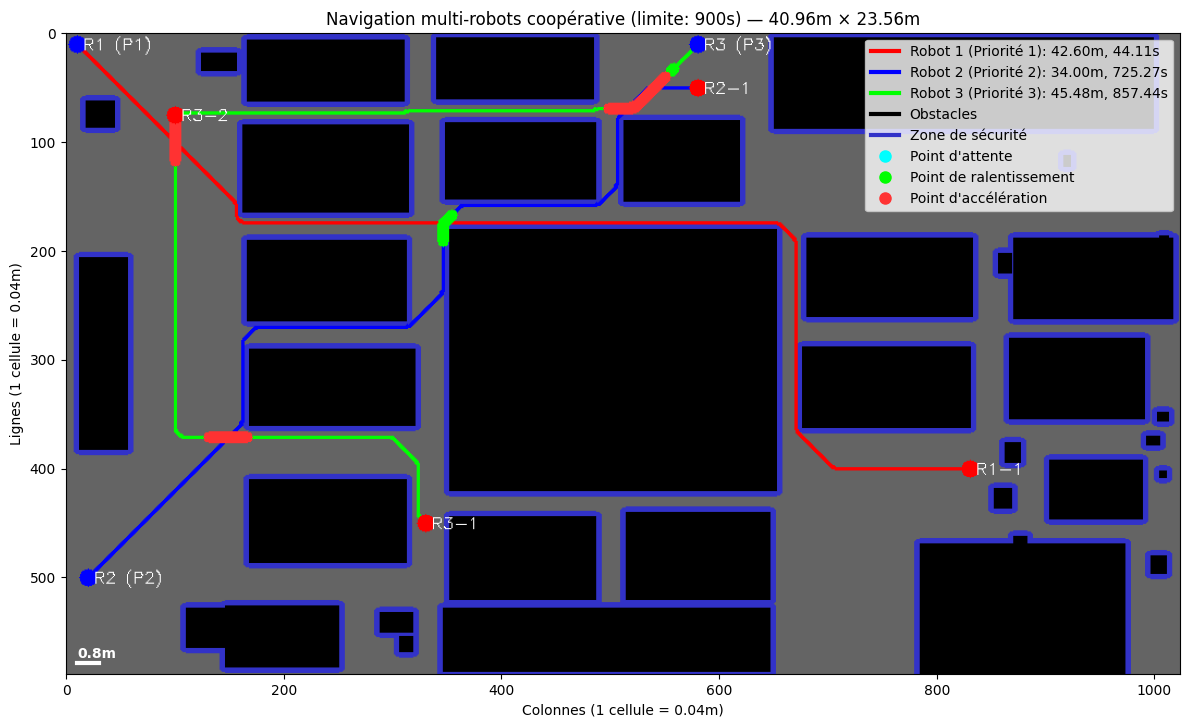

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from itertools import permutations
from queue import PriorityQueue
import math
import heapq
from collections import defaultdict
import copy

def manhattan_distance(point1, point2):
    return abs(point1[0] - point2[0]) + abs(point1[1] - point2[1])

def euclidean_distance(point1, point2):
    return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

def astar(map_binary, start, goal, diagonal_movement=False, safety_margin=5):
    """
    A* algorithm with safety distance from obstacles and smoother paths
    """
    h, w = map_binary.shape
    visited = set()
    came_from = {}
    g_score = {start: 0}
    f_score = {start: manhattan_distance(start, goal)}
    open_set = PriorityQueue()
    open_set.put((f_score[start], id(start), start))

    if diagonal_movement:
        directions = [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]
    else:
        # Pour forcer les angles de 90 degrés, on utilise uniquement des mouvements orthogonaux
        directions = [(-1,0), (1,0), (0,-1), (0,1)]

    while not open_set.empty():
        _, _, current = open_set.get()
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        visited.add(current)

        for dx, dy in directions:
            neighbor = (current[0]+dx, current[1]+dy)

            if not (0 <= neighbor[0] < h and 0 <= neighbor[1] < w):
                continue
                
            # Vérifier la distance de sécurité par rapport aux obstacles
            # On vérifie si le point est valide dans la carte dilatée
            if map_binary[neighbor] == 0:
                continue

            move_cost = 1.4 if (dx != 0 and dy != 0) else 1.0
            tentative_g = g_score[current] + move_cost

            # Ajouter une pénalité pour les changements de direction
            # afin de favoriser les chemins rectilignes
            if current in came_from:
                prev = came_from[current]
                prev_dir = (current[0] - prev[0], current[1] - prev[1])
                if (dx, dy) != prev_dir:
                    tentative_g += 1.5  # Pénalité pour changement de direction

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score[neighbor] = tentative_g + manhattan_distance(neighbor, goal)
                if neighbor not in visited:
                    open_set.put((f_score[neighbor], id(neighbor), neighbor))

    return None

def apply_safety_margin(map_binary, safety_cells):
    """
    Dilate les obstacles pour garantir une distance de sécurité
    """
    if safety_cells <= 0:
        return map_binary.copy()
        
    # Créer un élément structurant circulaire
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*safety_cells+1, 2*safety_cells+1))
    
    # Dilater les obstacles (0 = obstacle, 1 = espace libre)
    dilated_map = cv2.erode(map_binary.astype(np.uint8), kernel, iterations=1)
    
    return dilated_map

def add_curve_to_path(path, curve_radius_meters=2.5, point_size_meters=1.0):
    """
    Remplace les virages du chemin par des arcs de cercle lissés.
    Args:
        path: Liste de tuples (x, y)
        curve_radius_meters: Rayon minimal de courbe
        point_size_meters: Distance entre deux points dans le chemin
    Returns:
        Nouveau chemin lissé
    """
    if len(path) < 3:
        return path
    
    new_path = []
    r = max(curve_radius_meters, point_size_meters * 2)
    
    # Ajouter le premier point
    new_path.append(path[0])
    
    # Traiter tous les points intermédiaires
    for i in range(1, len(path) - 1):
        A = path[i - 1]  # Point précédent
        B = path[i]      # Point courant
        C = path[i + 1]  # Point suivant
        
        # Vecteurs AB et BC
        AB = (B[0] - A[0], B[1] - A[1])
        BC = (C[0] - B[0], C[1] - B[1])
        
        # Longueurs des segments
        AB_length = math.sqrt(AB[0]**2 + AB[1]**2)
        BC_length = math.sqrt(BC[0]**2 + BC[1]**2)
        
        # Vérifier si les segments sont trop courts
        if AB_length < 1e-5 or BC_length < 1e-5:
            new_path.append(B)
            continue
        
        # Vecteurs unitaires
        AB_unit = (AB[0] / AB_length, AB[1] / AB_length)
        BC_unit = (BC[0] / BC_length, BC[1] / BC_length)
        
        # Produit scalaire pour l'angle
        dot_product = AB_unit[0] * BC_unit[0] + AB_unit[1] * BC_unit[1]
        # Limiter pour éviter les erreurs numériques
        dot_product = max(-1.0, min(1.0, dot_product))
        
        # Angle entre les segments
        angle = math.acos(dot_product)
        
        # Si l'angle est trop petit, ne pas lisser (ligne presque droite)
        if angle < math.radians(5):
            new_path.append(B)
            continue
        
        # Produit vectoriel pour déterminer le sens de la courbe
        cross_product = AB_unit[0] * BC_unit[1] - AB_unit[1] * BC_unit[0]
        
        # Distance à laquelle commencer la courbe sur chaque segment
        # Limiter pour éviter que l'arc ne dépasse les segments
        tangent_dist = min(r / math.tan(angle/2), AB_length/2, BC_length/2)
        
        # Points où l'arc commence et finit
        P1 = (B[0] - AB_unit[0] * tangent_dist, B[1] - AB_unit[1] * tangent_dist)
        P2 = (B[0] + BC_unit[0] * tangent_dist, B[1] + BC_unit[1] * tangent_dist)
        
        # Calculer la bissectrice interne entre les deux segments
        # On calcule d'abord la somme des vecteurs unitaires
        bisect_x = AB_unit[0] + BC_unit[0]
        bisect_y = AB_unit[1] + BC_unit[1]
        bisect_length = math.sqrt(bisect_x**2 + bisect_y**2)
        
        # Si la bissectrice est trop courte, on utilise simplement B
        if bisect_length < 1e-5:
            new_path.append(B)
            continue
        
        # Normaliser la bissectrice
        bisect_unit = (bisect_x / bisect_length, bisect_y / bisect_length)
        
        # Pour placer le centre du cercle, on part perpendiculairement à la bissectrice
        # Selon le sens de rotation
        if cross_product < 0:  # Rotation horaire
            perp_bisect = (bisect_unit[1], -bisect_unit[0])
        else:  # Rotation anti-horaire
            perp_bisect = (-bisect_unit[1], bisect_unit[0])
        
        # Distance du centre par rapport au point B
        center_dist = (r / math.sin(angle/2)) if abs(math.sin(angle/2)) > 1e-5 else r  # Protection contre division par zéro
        
        # Centre du cercle - le placer à l'intérieur de l'angle
        center = (B[0] + perp_bisect[0] * center_dist, B[1] + perp_bisect[1] * center_dist)
        
        # Calcul des angles de début et de fin pour l'arc
        start_angle = math.atan2(P1[1] - center[1], P1[0] - center[0])
        end_angle = math.atan2(P2[1] - center[1], P2[0] - center[0])
        
        # Assurer que l'arc suit le bon sens de rotation
        if cross_product < 0:  # Rotation horaire
            if end_angle > start_angle:
                end_angle -= 2 * math.pi
        else:  # Rotation anti-horaire
            if end_angle < start_angle:
                end_angle += 2 * math.pi
        
        # Ajouter le point P1 si nécessaire
        new_path.append(P1)
        
        # Calculer la longueur d'arc et le nombre de points à générer
        arc_length = abs(end_angle - start_angle) * r
        num_points = max(1, round(arc_length / point_size_meters))
        
        # Générer les points intermédiaires de l'arc
        for j in range(1, num_points):
            t = j / num_points
            angle_t = start_angle + t * (end_angle - start_angle)
            arc_x = center[0] + r * math.cos(angle_t)
            arc_y = center[1] + r * math.sin(angle_t)
            new_path.append((arc_x, arc_y))
    
    # Ajouter le dernier point
    new_path.append(path[-1])
    
    return new_path

def solve_tsp(map_binary, start, goals, use_astar=True, diagonal_movement=True, 
              curve_radius_meters=2.5, point_size_meters=0.04, safety_margin_meters=0.2):
    """
    Résout le TSP avec A*, marge de sécurité, et lissage des virages.
    
    Args:
        map_binary: carte binaire (0 = obstacle, 1 = libre)
        start: point de départ (x, y)
        goals: liste des points à visiter
        use_astar: utiliser A* ou non
        diagonal_movement: mouvement en diagonale autorisé
        curve_radius_meters: rayon minimal des virages
        point_size_meters: résolution en mètres par cellule
        safety_margin_meters: distance de sécurité autour des obstacles

    Returns:
        best_path: chemin total lissé
        min_total_length: longueur totale du chemin
        best_segments: liste des segments individuels
        safe_map: carte binaire avec marge de sécurité appliquée
    """
    best_path = None
    min_total_length = float("inf")
    best_segments = []

    # Appliquer la marge de sécurité
    safety_margin_cells = int(safety_margin_meters / point_size_meters)
    safe_map = apply_safety_margin(map_binary, safety_margin_cells)

    all_points = [start] + goals
    distance_matrix = {}

    # Étape 1 : Calculer les segments entre tous les couples
    for i, p1 in enumerate(all_points):
        for j, p2 in enumerate(all_points[i + 1:], i + 1):
            if use_astar:
                segment = astar(safe_map, p1, p2, diagonal_movement)
                if segment is None:
                    distance_matrix[(p1, p2)] = None
                    distance_matrix[(p2, p1)] = None
                else:
                    # Lissage des virages
                    smoothed = add_curve_to_path(segment, curve_radius_meters, point_size_meters)
                    distance_matrix[(p1, p2)] = smoothed
                    distance_matrix[(p2, p1)] = smoothed[::-1]  # Inverser pour le chemin inverse
            else:
                distance_matrix[(p1, p2)] = None
                distance_matrix[(p2, p1)] = None

    # Étape 2 : Tester toutes les permutations de TSP
    for perm in permutations(goals):
        full_path = []
        total_length = 0
        valid_path = True
        current = start
        segments = []

        for target in perm:
            segment = distance_matrix.get((current, target))
            if segment is None:
                valid_path = False
                break
            if full_path:
                full_path.extend(segment[1:])  # éviter doublon
            else:
                full_path.extend(segment)
            segments.append(segment)
            total_length += len(segment) * point_size_meters  # longueur réelle
            current = target

        if valid_path and total_length < min_total_length:
            best_path = full_path
            best_segments = segments
            min_total_length = total_length

    return best_path, min_total_length, best_segments, safe_map

def load_or_create_map(image=None, obstacle_density=0.2, width=500, height=500):
    if image is not None:
        try:
            img = image.copy()
            if img is None:
                raise ValueError("Image non valide")
            map_binary = (img == 0).astype(np.uint8)
            return map_binary
        except Exception as e:
            print(f"Erreur : {e} — carte aléatoire générée.")

    # Si image n'est pas disponible, on crée une carte aléatoire
    map_binary = np.ones((height, width), dtype=np.uint8)
    obstacle_mask = np.random.random((height, width)) < obstacle_density
    map_binary[obstacle_mask] = 0
    map_binary[0:5, 0:5] = 1  # Zone de départ
    map_binary[-5:, -5:] = 1  # Zone d'arrivée
    
    # Ajouter quelques obstacles structurés pour tester les courbes
    map_binary[10:30, 20] = 0  # Mur vertical
    map_binary[40, 30:50] = 0  # Mur horizontal

    return map_binary

# ----- NOUVELLES FONCTIONS POUR LA NAVIGATION MULTI-ROBOTS -----


class Robot:
    def __init__(self, id, start, goals, speed=1.0, priority=None):
        """
        Initialise un robot
        
        Args:
            id: identifiant unique du robot
            start: position de départ (x, y)
            goals: liste des objectifs à atteindre [(x1, y1), (x2, y2), ...]
            speed: vitesse en m/s
            priority: priorité (plus le chiffre est bas, plus la priorité est haute)
        """
        self.id = id
        self.start = start
        self.goals = goals
        self.speed = speed
        
        # Si aucune priorité n'est fournie, utilise l'ID comme priorité par défaut
        self.priority = priority if priority is not None else id
        
        # Chemin planifié avec les temps associés [(point, temps), ...]
        self.timed_path = []
        
        # Chemin avec temps d'arrivée ajustés pour éviter les collisions
        self.adjusted_timed_path = []
        
        # Segments du chemin pour la visualisation
        self.path_segments = []
        
        # Marqueur pour indiquer si le robot attend à certains points
        self.wait_points = set()
        
        # Temps total de parcours
        self.total_time = 0
        
        # Longueur du chemin
        self.path_length = 0
def calculate_arrival_times(path, speed, point_size_meters):
    """
    Calcule les temps d'arrivée à chaque point du chemin
    
    Args:
        path: liste des points du chemin [(x1, y1), (x2, y2), ...]
        speed: vitesse du robot en m/s
        point_size_meters: taille d'une cellule en mètres
        
    Returns:
        Liste de tuples (point, temps d'arrivée)
    """
   
    if path is None or len(path) == 0:
        return []  # Gérer le cas où le chemin est vide ou None
        
    timed_path = []
    current_time = 0.0
    
    timed_path.append((path[0], current_time))
    
    for i in range(1, len(path)):
        # Calculer la distance euclidienne entre les points
        dx = path[i][0] - path[i-1][0]
        dy = path[i][1] - path[i-1][1]
        distance = math.sqrt(dx*dx + dy*dy) * point_size_meters
        
        # Calculer le temps nécessaire pour parcourir cette distance
        travel_time = distance / speed
        
        # Mettre à jour le temps cumulatif
        current_time += travel_time
        
        timed_path.append((path[i], current_time))
    
    return timed_path

def find_path_intersections(robots, safety_distance_meters, point_size_meters, time_threshold=3.0):
    """
    Identifie les intersections entre les chemins des robots
    
    Args:
        robots: liste des robots
        safety_distance_meters: distance de sécurité en mètres
        point_size_meters: taille d'une cellule en mètres
        time_threshold: seuil de temps en secondes pour considérer qu'il y a risque de collision
        
    Returns:
        Liste des conflits (robot1, robot2, point_intersection, temps1, temps2, idx1, idx2)
    """
    conflicts = []
    safety_distance_cells = safety_distance_meters / point_size_meters
    
    # Vérifier que les robots ont des chemins valides
    valid_robots = [robot for robot in robots if hasattr(robot, 'timed_path') and robot.timed_path]
    
    # Initialiser les attributs d'intersection pour chaque robot
    for robot in valid_robots:
        robot.intersection_points = []
    
    # Comparer les chemins de chaque paire de robots
    for i, robot1 in enumerate(valid_robots):
        for j, robot2 in enumerate(valid_robots[i+1:], i+1):
            # Vérifier chaque segment de chemin
            for idx1 in range(len(robot1.timed_path)-1):
                point1_a, time1_a = robot1.timed_path[idx1]
                point1_b, time1_b = robot1.timed_path[idx1+1]
                
                for idx2 in range(len(robot2.timed_path)-1):
                    point2_a, time2_a = robot2.timed_path[idx2]
                    point2_b, time2_b = robot2.timed_path[idx2+1]
                    
                    # Vérifier si les segments temporels se chevauchent
                    if max(time1_a, time2_a) <= min(time1_b, time2_b) + time_threshold:
                        # Calculer les positions moyennes pour approximer le point d'intersection
                        avg_time1 = (time1_a + time1_b) / 2
                        avg_time2 = (time2_a + time2_b) / 2
                        
                        # Calculer les positions interpolées aux temps moyens
                        mid_point1 = interpolate_position(point1_a, point1_b, time1_a, time1_b, avg_time1)
                        mid_point2 = interpolate_position(point2_a, point2_b, time2_a, time2_b, avg_time2)
                        
                        # Calculer la distance entre les points intermédiaires
                        dist = euclidean_distance(mid_point1, mid_point2)
                        
                        # Si les points sont proches (à l'intérieur de la distance de sécurité)
                        if dist <= safety_distance_cells:
                            # Si les temps d'arrivée sont proches (à l'intérieur du seuil de temps)
                            time_diff = abs(avg_time1 - avg_time2)
                            
                            if time_diff <= time_threshold:
                                # Point d'intersection = point moyen entre les deux robots
                                intersection_point = (
                                    (mid_point1[0] + mid_point2[0])/2, 
                                    (mid_point1[1] + mid_point2[1])/2
                                )
                                
                                # Ajouter le conflit à la liste
                                conflicts.append((robot1, robot2, intersection_point, avg_time1, avg_time2, idx1, idx2))
                                
                                # Ajouter le point d'intersection aux données des robots
                                robot1.intersection_points.append(intersection_point)
                                robot2.intersection_points.append(intersection_point)
                                
                               
    
    return conflicts

def interpolate_position(pos1, pos2, time1, time2, target_time):
    """
    Interpole la position entre deux points en fonction du temps
    """
    if abs(time2 - time1) < 1e-6:  # Éviter division par zéro
        return pos1
    
    alpha = (target_time - time1) / (time2 - time1)
    alpha = max(0, min(1, alpha))  # Limiter entre 0 et 1
    
    return (
        pos1[0] + alpha * (pos2[0] - pos1[0]),
        pos1[1] + alpha * (pos2[1] - pos1[1])
    )

def resolve_conflicts(robots, conflicts, delay_penalty=1.5, max_time_limit=900.0):
    """
    Résout les conflits entre robots en ajustant les vitesses ou en retardant certains robots,
    avec une limite maximale sur le temps total de parcours.

    Args:
        robots: liste des robots
        conflicts: liste des conflits à résoudre
        delay_penalty: facteur de pénalité pour les retards (pour éviter trop de retards)
        max_time_limit: temps maximal autorisé pour un robot (en secondes)
        
    Returns:
        Liste des robots avec chemins temporels ajustés et liste des intersections résolues
    """
    # Trier les conflits par ordre chronologique
    conflicts.sort(key=lambda x: min(x[3], x[4]))

    # Initialiser les délais cumulés et le temps restant pour chaque robot
    cumulative_delays = {robot.id: 0 for robot in robots}
    
    # Calculer le temps de base de chaque robot (avant résolution des conflits)
    for robot in robots:
        if robot.timed_path:
            robot.base_time = robot.timed_path[-1][1]
            robot.remaining_time = max_time_limit - robot.base_time
        else:
            robot.base_time = 0
            robot.remaining_time = max_time_limit

    resolved_intersections = []

    for robot1, robot2, intersection_point, time1, time2, idx1, idx2 in conflicts:
        # Déterminer la priorité
        if robot1.priority < robot2.priority:
            priority_robot, non_priority_robot = robot1, robot2
            priority_time, non_priority_time = time1, time2
            priority_idx, non_priority_idx = idx1, idx2
            priority_reason = f"Robot {robot1.id} prioritaire (niveau {robot1.priority} < {robot2.priority})"
        elif robot2.priority < robot1.priority:
            priority_robot, non_priority_robot = robot2, robot1
            priority_time, non_priority_time = time2, time1
            priority_idx, non_priority_idx = idx2, idx1
            priority_reason = f"Robot {robot2.id} prioritaire (niveau {robot2.priority} < {robot1.priority})"
        else:
            if time1 <= time2:
                priority_robot, non_priority_robot = robot1, robot2
                priority_time, non_priority_time = time1, time2
                priority_idx, non_priority_idx = idx1, idx2
                priority_reason = f"Robot {robot1.id} prioritaire (arrivée plus tôt: {time1:.2f}s < {time2:.2f}s)"
            else:
                priority_robot, non_priority_robot = robot2, robot1
                priority_time, non_priority_time = time2, time1
                priority_idx, non_priority_idx = idx2, idx1
                priority_reason = f"Robot {robot2.id} prioritaire (arrivée plus tôt: {time2:.2f}s < {time1:.2f}s)"

        # Calculer le délai à appliquer pour éviter la collision
        delay = priority_time + 3.0 - non_priority_time  # 3 secondes de marge
        if delay <= 0:
            delay = 1.0  # Délai minimal pour garantir la visualisation

        # Vérifier si ce délai ne va pas dépasser la limite de temps
        # Estimation du temps final après ce délai
        estimated_final_time = non_priority_robot.base_time + cumulative_delays[non_priority_robot.id] + delay
        
        # Si le temps estimé dépasse la limite, ajuster le délai
        if estimated_final_time > max_time_limit:
            # Calculer le délai maximal possible
            max_delay = max(0, non_priority_robot.remaining_time - cumulative_delays[non_priority_robot.id])
            
            # Si aucun délai n'est possible, essayer d'accélérer le robot
            if max_delay < 1.0:  # Si on ne peut même pas avoir le délai minimal
                # On pourrait ajuster la vitesse du robot plutôt que d'ajouter un délai
                speed_factor = 1.5  # Accélérer le robot de 50%
                
                # Recalculer les temps pour le reste du parcours avec la nouvelle vitesse
                if non_priority_idx < len(non_priority_robot.timed_path) - 1:
                    remaining_distance = 0
                    current_point = non_priority_robot.timed_path[non_priority_idx][0]
                    
                    # Calculer la distance restante
                    for k in range(non_priority_idx + 1, len(non_priority_robot.timed_path)):
                        next_point = non_priority_robot.timed_path[k][0]
                        dx = next_point[0] - current_point[0]
                        dy = next_point[1] - current_point[1]
                        remaining_distance += (dx**2 + dy**2)**0.5
                        current_point = next_point
                    
                    # Ajuster les temps
                    current_time = non_priority_robot.timed_path[non_priority_idx][1]
                    for k in range(non_priority_idx + 1, len(non_priority_robot.timed_path)):
                        point, t = non_priority_robot.timed_path[k]
                        time_diff = t - non_priority_robot.timed_path[k-1][1]
                        non_priority_robot.timed_path[k] = (point, current_time + time_diff / speed_factor)
                        current_time = non_priority_robot.timed_path[k][1]
                
                # Enregistrer la raison de l'accélération
                acceleration_point = non_priority_robot.timed_path[non_priority_idx][0]
                if not hasattr(non_priority_robot, 'acceleration_points'):
                    non_priority_robot.acceleration_points = set()
                    non_priority_robot.acceleration_reasons = {}
                    non_priority_robot.visible_acceleration_points = []
                
                non_priority_robot.acceleration_points.add(acceleration_point)
                non_priority_robot.acceleration_reasons[acceleration_point] = f"{priority_reason} - accélération pour respecter limite de 900s"
                non_priority_robot.visible_acceleration_points.append((acceleration_point, priority_reason, speed_factor))
                
                # Mettre à jour le temps final estimé
                if non_priority_robot.timed_path:
                    non_priority_robot.total_time = non_priority_robot.timed_path[-1][1]
                
                # Ne pas ajouter de délai dans ce cas
                delay = 0
            else:
                # Ajuster le délai pour ne pas dépasser la limite
                delay = max_delay
                priority_reason += f" (délai ajusté à {delay:.2f}s pour limite de 900s)"
        
        # Stocker l'information sur l'intersection
        intersection_info = {
            "point": intersection_point,
            "priority_robot": priority_robot.id,
            "non_priority_robot": non_priority_robot.id,
            "time": (priority_time + non_priority_time) / 2,
            "reason": priority_reason
        }
        resolved_intersections.append(intersection_info)

        # Appliquer le délai si nécessaire
        if delay > 0:
            # S'assurer que les wait_points et wait_reasons sont des attributs du robot
            if not hasattr(non_priority_robot, 'wait_points'):
                non_priority_robot.wait_points = set()
            if not hasattr(non_priority_robot, 'wait_reasons'):
                non_priority_robot.wait_reasons = {}
            if not hasattr(non_priority_robot, 'slow_points'):
                non_priority_robot.slow_points = set()
            if not hasattr(non_priority_robot, 'slow_reasons'):
                non_priority_robot.slow_reasons = {}

            if non_priority_idx < 2:
                # Le robot non prioritaire est trop proche, on applique un simple retard
                for k in range(non_priority_idx, len(non_priority_robot.timed_path)):
                    point, t = non_priority_robot.timed_path[k]
                    non_priority_robot.timed_path[k] = (point, t + delay)

                wait_point = non_priority_robot.timed_path[non_priority_idx][0]
                non_priority_robot.wait_points.add(wait_point)
                non_priority_robot.wait_reasons[wait_point] = priority_reason
                
                # Ajouter un attribut visible pour le point d'attente
                if not hasattr(non_priority_robot, 'visible_wait_points'):
                    non_priority_robot.visible_wait_points = []
                non_priority_robot.visible_wait_points.append((wait_point, priority_reason, delay))
                
            else:
                # Ralentir progressivement sur les segments précédant l'intersection
                start_idx = max(0, non_priority_idx - 5)
                total_segment_time = 0
                segment_durations = []

                for k in range(start_idx + 1, non_priority_idx + 1):
                    t1 = non_priority_robot.timed_path[k - 1][1]
                    t2 = non_priority_robot.timed_path[k][1]
                    duration = t2 - t1
                    segment_durations.append((k, duration))
                    total_segment_time += duration

                if total_segment_time > 0:
                    # Répartir le délai
                    for k, duration in segment_durations:
                        segment_delay = (duration / total_segment_time) * delay
                        for m in range(k, len(non_priority_robot.timed_path)):
                            point, t = non_priority_robot.timed_path[m]
                            non_priority_robot.timed_path[m] = (point, t + segment_delay)

                    slow_point = non_priority_robot.timed_path[start_idx][0]
                    non_priority_robot.slow_points.add(slow_point)
                    non_priority_robot.slow_reasons[slow_point] = priority_reason
                    
                    # Ajouter un attribut visible pour le point de ralentissement
                    if not hasattr(non_priority_robot, 'visible_slow_points'):
                        non_priority_robot.visible_slow_points = []
                    non_priority_robot.visible_slow_points.append((slow_point, priority_reason, delay))

            cumulative_delays[non_priority_robot.id] += delay
            
            # Mettre à jour le temps restant
            non_priority_robot.remaining_time -= delay

        # Mettre à jour le temps total du robot non prioritaire après avoir ajouté le délai
        if non_priority_robot.timed_path:
            non_priority_robot.total_time = non_priority_robot.timed_path[-1][1]

    # Mise à jour des temps finaux pour tous les robots
    for robot in robots:
        if robot.timed_path:
            robot.total_time = robot.timed_path[-1][1]

    return robots, resolved_intersections

def generate_multi_robot_paths(map_binary, robots, point_size_meters=0.04, 
                              safety_margin_meters=0.2, robot_safety_distance_meters=1.0,
                              curve_radius_meters=2.5, diagonal_movement=False,
                              time_threshold=3.0, max_time_limit=900.0):
    """
    Génère les chemins pour plusieurs robots en évitant les collisions avec une limite de temps maximale
    """
    # Appliquer la marge de sécurité pour les obstacles
    safety_margin_cells = int(safety_margin_meters / point_size_meters)
    safe_map = apply_safety_margin(map_binary, safety_margin_cells)
    
    # Calculer le chemin optimal pour chaque robot
    for robot in robots:
        path = None
        if len(robot.goals) > 1:
            # Si le robot a plusieurs objectifs, résoudre le TSP
            path, length, segments, _ = solve_tsp(
                safe_map, robot.start, robot.goals,
                use_astar=True,
                diagonal_movement=diagonal_movement,
                curve_radius_meters=curve_radius_meters,
                point_size_meters=point_size_meters,
                safety_margin_meters=safety_margin_meters
            )
            if path:  # Vérifier que le chemin existe
                robot.path_segments = segments
                robot.path = path
            else:
                print(f"Aucun chemin TSP trouvé pour le robot {robot.id}!")
                robot.path_segments = []
                robot.path = []
                continue
        else:
            # Si le robot n'a qu'un seul objectif, utiliser A* directement
            segment = astar(safe_map, robot.start, robot.goals[0], diagonal_movement=diagonal_movement)
            if segment:
                path = add_curve_to_path(segment, curve_radius_meters, point_size_meters)
                robot.path_segments = [path]
                robot.path = path
            else:
                print(f"Aucun chemin trouvé pour le robot {robot.id} vers l'objectif {robot.goals[0]}!")
                robot.path_segments = []
                robot.path = []
                continue
        
        # Calculer les temps d'arrivée à chaque point si le chemin existe
        if path:
            robot.timed_path = calculate_arrival_times(robot.path, robot.speed, point_size_meters)
            robot.path_length = len(robot.path) * point_size_meters
            
            # S'assurer que le temps total est défini correctement
            if robot.timed_path:
                robot.total_time = robot.timed_path[-1][1]
                
                # Vérifier si le temps de base dépasse déjà la limite
                if robot.total_time > max_time_limit:
                    # Ajuster la vitesse pour respecter la limite
                    speed_factor = robot.total_time / max_time_limit * 1.05  # 5% de marge
                    print(f"Robot {robot.id}: temps initial ({robot.total_time:.2f}s) > limite de {max_time_limit}s.")
                    print(f"Augmentation de vitesse par un facteur {speed_factor:.2f}")
                    
                    # Recalculer les temps avec la nouvelle vitesse
                    new_timed_path = []
                    base_time = robot.timed_path[0][1]
                    new_timed_path.append((robot.timed_path[0][0], base_time))
                    
                    for i in range(1, len(robot.timed_path)):
                        point, time = robot.timed_path[i]
                        time_diff = time - robot.timed_path[i-1][1]
                        new_time = new_timed_path[-1][1] + time_diff / speed_factor
                        new_timed_path.append((point, new_time))
                    
                    robot.timed_path = new_timed_path
                    robot.speed *= speed_factor
                    robot.total_time = robot.timed_path[-1][1]
                    print(f"Nouveau temps estimé: {robot.total_time:.2f}s avec vitesse {robot.speed:.2f}m/s")
            else:
                robot.total_time = 0
                
            # Initialiser la liste des points d'intersection
            robot.intersection_points = []
        else:
            robot.timed_path = []
            robot.path_length = 0
            robot.total_time = 0
            robot.intersection_points = []
    
    # Filtrer les robots sans chemin valide
    valid_robots = [robot for robot in robots if robot.timed_path]
    
    # Identifier les intersections et conflits potentiels seulement pour les robots avec des chemins valides
    resolved_intersections = []
    if len(valid_robots) > 1:  # Au moins 2 robots pour avoir un conflit
        conflicts = find_path_intersections(valid_robots, robot_safety_distance_meters, point_size_meters, time_threshold)
        
        # Résoudre les conflits s'il y en a
        if conflicts:
            valid_robots, resolved_intersections = resolve_conflicts(valid_robots, conflicts, max_time_limit=max_time_limit)
            
            # Màj des robots originaux avec les robots valides mis à jour
            for updated_robot in valid_robots:
                for i, orig_robot in enumerate(robots):
                    if orig_robot.id == updated_robot.id:
                        robots[i] = updated_robot
                        break
    
    # Mettre à jour les temps totaux après toutes les modifications
    for robot in robots:
        if robot.timed_path:
            robot.total_time = robot.timed_path[-1][1]
            
            # Dernière vérification de la limite de temps
            if robot.total_time > max_time_limit:
                print(f"⚠️ Robot {robot.id}: temps final ({robot.total_time:.2f}s) dépasse la limite de {max_time_limit}s.")
        else:
            robot.total_time = 0
    
    return robots, safe_map, resolved_intersections

def visualize_multi_robot_paths(map_binary, robots, safe_map=None, intersections=None, point_size_meters=0.04):
    """
    Visualise les chemins de plusieurs robots
    
    Args:
        map_binary: carte binaire (0 = obstacle, 1 = libre)
        robots: liste des robots avec leurs chemins
        safe_map: carte avec marge de sécurité
        intersections: liste des intersections résolues
        point_size_meters: taille d'une cellule en mètres
    """
    height, width = map_binary.shape
    real_width_meters = width * point_size_meters
    real_height_meters = height * point_size_meters
    
    # Créer une visualisation RGB
    if safe_map is not None:
        # Visualiser la carte avec marge de sécurité
        map_vis = np.zeros((height, width, 3), dtype=np.uint8)
        map_vis[map_binary == 1] = [100, 100, 100]  # Zone libre en gris clair
        map_vis[map_binary == 0] = [0, 0, 0]  # Obstacles en noir
        # Zones de sécurité (dans la carte originale mais pas dans la carte dilatée)
        safety_zone_mask = (map_binary == 1) & (safe_map == 0)
        map_vis[safety_zone_mask] = [50, 50, 200]  # Zone de sécurité en bleu
    else:
        map_vis = np.stack([map_binary]*3, axis=-1) * 255
        map_vis = map_vis.astype(np.uint8)
        map_vis[map_binary == 1] = [100, 100, 100]  # Zone libre en gris clair
        map_vis[map_binary == 0] = [0, 0, 0]  # Obstacles en noir

    # Couleurs pour chaque robot (HSV pour meilleure séparation)
    colors = []
    num_robots = len(robots)
    for i in range(num_robots):
        hue = int(360 * i / max(1, num_robots))  # Protéger contre division par zéro
        hsv_color = np.array([[[hue, 255, 255]]], dtype=np.uint8)
        rgb_color = cv2.cvtColor(hsv_color, cv2.COLOR_HSV2RGB)[0][0]
        colors.append(tuple(int(c) for c in rgb_color))  # RGB sur 255

    # Fonction pour normaliser RGB de 0–255 → 0–1 (pour matplotlib)
    def normalize_rgb(color):
       return tuple([c / 255.0 for c in color])
    
    # Dessiner les chemins des robots
    for i, robot in enumerate(robots):
        if i >= len(colors):  # Protéger contre l'indexation hors limites
            break
            
        color = colors[i]
        
        # Dessiner chaque segment du chemin
        for segment in robot.path_segments:
            for j in range(len(segment)-1):
                pt1 = (int(segment[j][1]), int(segment[j][0]))
                pt2 = (int(segment[j+1][1]), int(segment[j+1][0]))
                cv2.line(map_vis, pt1, pt2, color, 2)
        
        # Marquer les points d'attente
        if hasattr(robot, 'wait_points'):
            for point in robot.wait_points:
                cv2.circle(map_vis, (int(point[1]), int(point[0])), 5, (0, 255, 255), -1)  # Jaune
        
        # Marquer les points de ralentissement
        if hasattr(robot, 'slow_points'):
            for point in robot.slow_points:
                cv2.circle(map_vis, (int(point[1]), int(point[0])), 5, (0, 255, 0), -1)  # Vert
        
        # Marquer les points d'accélération
        if hasattr(robot, 'acceleration_points'):
            for point in robot.acceleration_points:
                cv2.circle(map_vis, (int(point[1]), int(point[0])), 5, (255, 50, 50), -1)  # Rouge clair
        
        # Marquer le point de départ
        cv2.circle(map_vis, (robot.start[1], robot.start[0]), 8, (0, 0, 255), -1)  # Rouge
        cv2.putText(map_vis, f"R{robot.id} (P{robot.priority})", (robot.start[1]+5, robot.start[0]+5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        # Marquer les objectifs
        for g, goal in enumerate(robot.goals):
            cv2.circle(map_vis, (goal[1], goal[0]), 8, (255, 0, 0), -1)  # Bleu
            cv2.putText(map_vis, f"R{robot.id}-{g+1}", (goal[1]+5, goal[0]+5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    

    plt.figure(figsize=(12, 10))
    plt.imshow(map_vis)
    title = f"Navigation multi-robots coopérative (limite: 900s)"
    plt.title(f"{title} — {real_width_meters:.2f}m × {real_height_meters:.2f}m")
    plt.xlabel(f"Colonnes (1 cellule = {point_size_meters}m)")
    plt.ylabel(f"Lignes (1 cellule = {point_size_meters}m)")

    # Scalebar
    scalebar_length_cells = 20
    scalebar_length_meters = scalebar_length_cells * point_size_meters
    plt.plot([10, 10 + scalebar_length_cells], [height-10, height-10], 'w-', linewidth=3)
    plt.text(10, height-15, f"{scalebar_length_meters}m", color='white', fontweight='bold')

    # Légende des robots
    handles = []
    for i, robot in enumerate(robots):
        # Vérifier que le robot a un temps de trajet et une longueur de chemin valides
        path_length = getattr(robot, 'path_length', 0)
        total_time = getattr(robot, 'total_time', 0)
        
        # Indiquer si le temps dépasse la limite
        time_status = ""
        if total_time > 900:
            time_status = " [DÉPASSE LA LIMITE]"
        
        handles.append(plt.Line2D([0], [0], color=normalize_rgb(colors[i]), lw=3, 
                                  label=f"Robot {robot.id} (Priorité {robot.priority}): {path_length:.2f}m, {total_time:.2f}s{time_status}"))
    
    # Ajouter la légende des obstacles et zones de sécurité
    handles.append(plt.Line2D([0], [0], color='black', lw=3, label='Obstacles'))
    if safe_map is not None:
        handles.append(plt.Line2D([0], [0], color=(50/255, 50/255, 200/255), lw=3, label='Zone de sécurité'))
    
    # Point d'attente pour les conflits
    handles.append(plt.Line2D([0], [0], marker='o', color=(0, 1, 1), 
                             markersize=8, label='Point d\'attente', linestyle='None'))
    
    # Point de ralentissement
    handles.append(plt.Line2D([0], [0], marker='o', color=(0, 1, 0), 
                             markersize=8, label='Point de ralentissement', linestyle='None'))
    
    # Point d'accélération
    handles.append(plt.Line2D([0], [0], marker='o', color=(1, 0.2, 0.2), 
                             markersize=8, label='Point d\'accélération', linestyle='None'))
    
    plt.legend(handles=handles, loc='upper right')
    plt.tight_layout()
    
    # Afficher les statistiques
    print("\nStatistiques des robots:")
    print("ID | Priorité | Distance (m) | Temps (s) | Statut")
    print("-" * 60)
    total_travel_time = 0
    max_travel_time = 0
    
    for robot in robots:
        # Vérifier que le robot a un temps de trajet et une longueur de chemin valides
        path_length = getattr(robot, 'path_length', 0)
        total_time = getattr(robot, 'total_time', 0)
        
        status = "OK" if total_time <= 900 else "DÉPASSE LA LIMITE"
        
        print(f"{robot.id:2d} | {robot.priority:8d} | {path_length:11.2f} | {total_time:8.2f} | {status}")
        total_travel_time += total_time
        max_travel_time = max(max_travel_time, total_time)
    
    if len(robots) > 0:
        print(f"\nTemps de trajet total: {total_travel_time:.2f}s")
        print(f"Temps de trajet maximal: {max_travel_time:.2f}s")
        print(f"Temps de trajet moyen: {total_travel_time/len(robots):.2f}s")
    else:
        print("\nAucun robot avec un chemin valide.")



def main():
    """
    Fonction principale pour démontrer l'utilisation du système
    """
    # Créer une carte
    map_size = 100
    map_binary = load_or_create_map(obstacle_map_dilated,obstacle_density=0.1, width=800, height=600)
    
    
    
    # Paramètres
    point_size_meters = 0.04  # Taille d'une cellule en mètres
    safety_margin_meters = 0.2  # Marge de sécurité autour des obstacles
    robot_safety_distance_meters = 0.5  # Distance de sécurité entre robots
    
    # Définir les robots
    robots = [
        Robot(id=1, start=(10, 10), goals=[(400, 830)], speed=1.0, priority=1),
        Robot(id=2, start=(500, 20), goals=[(50, 580)], speed=1.0, priority=2),
        Robot(id=3, start=(10, 580), goals=[(450, 330), (75, 100)], speed=1.0, priority=3)
    ]
    
     # Générer les chemins
    robots, safe_map, intersections = generate_multi_robot_paths(
        map_binary, robots,
        point_size_meters=point_size_meters,
        safety_margin_meters=safety_margin_meters,
        robot_safety_distance_meters=robot_safety_distance_meters,
        curve_radius_meters=1.0,
        diagonal_movement=True,
        time_threshold=100  # Plus sensible aux intersections
    )
    
    # Visualiser les chemins
    visualize_multi_robot_paths(map_binary, robots, safe_map, intersections, point_size_meters)
    
   
if __name__ == "__main__":
    main()